
Found https://www.shutterstock.com/image-photo/delicious-hot-dogs-sauces-lettuce-600w-2652600935.jpg locally at delicious-hot-dogs-sauces-lettuce-600w-2652600935.jpg
image 1/1 /content/delicious-hot-dogs-sauces-lettuce-600w-2652600935.jpg: 448x640 2 hot dogs, 123.7ms
Speed: 3.1ms preprocess, 123.7ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
YOLOv8 Detection Results:


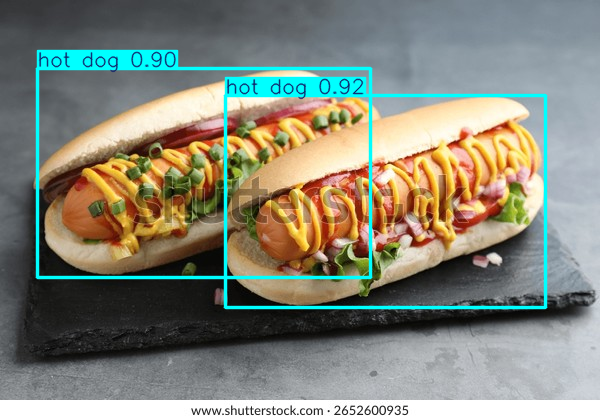

Found: hot dog with 0.92 confidence
Found: hot dog with 0.90 confidence


In [ ]:
# 1. Install Ultralytics
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow # Use this for Google Colab
# import matplotlib.pyplot as plt # Use this if NOT in Colab

# 2. Load the pre-trained Nano model
yolo_model = YOLO("yolov8n.pt")

# 3. Define the image URL
img_url = "https://www.shutterstock.com/image-photo/delicious-hot-dogs-sauces-lettuce-600w-2652600935.jpg"

# 4. Run detection (YOLOv8 can download directly from a URL)
results = yolo_model(img_url)

# 5. Plot the results (this draws the boxes and labels)
res_plotted = results[0].plot()

# 6. Display the image
print("YOLOv8 Detection Results:")
cv2_imshow(res_plotted)

# Optional: Print out exactly what it found
for box in results[0].boxes:
    class_id = int(box.cls[0])
    label = yolo_model.names[class_id]
    conf = float(box.conf[0])
    print(f"Found: {label} with {conf:.2f} confidence")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
HOT DOG! (Confidence: 0.63)


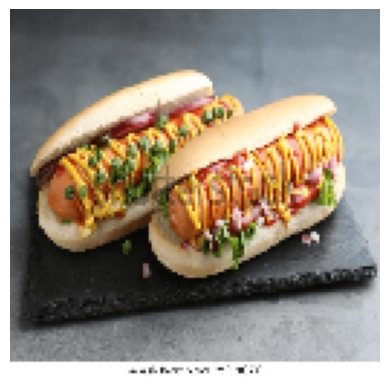

In [ ]:
import numpy as np
import requests
from io import BytesIO
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_image(img_url):
    # 1. Download image
    try:
        response = requests.get(img_url)
        img = image.load_img(BytesIO(response.content), target_size=(IMG_HEIGHT, IMG_WIDTH))

        # 2. Preprocess the image
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0  # Rescale to [0,1]

        # 3. Predict using your final trained model
        prediction = final_model.predict(img_array)[0][0]

        # 4. Interpret the sigmoid output (0 to 1)
        if prediction > 0.5:
            print(f"HOT DOG! (Confidence: {prediction:.2f})")
        else:
            print(f"NOT A HOT DOG! (Confidence: {1 - prediction:.2f})")

        # 5. Show the image we just predicted
        plt.imshow(img)
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error loading image: {e}")

# REPLACE the URL below with a real link to a hot dog photo from Google Images
predict_image("https://www.shutterstock.com/image-photo/delicious-hot-dogs-sauces-lettuce-600w-2652600935.jpg")

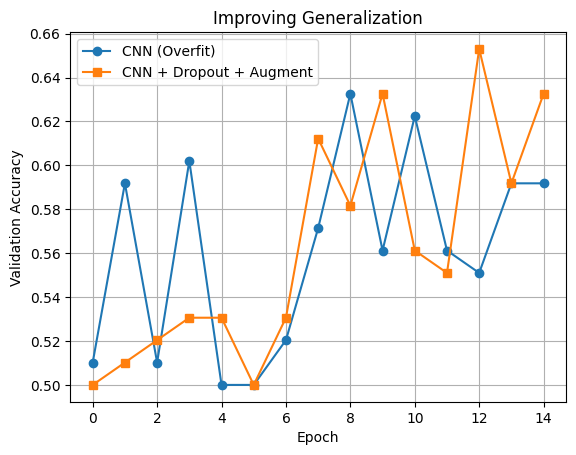

In [ ]:
import matplotlib.pyplot as plt

# Fixed syntax: straight quotes and no spaces around the dots
plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)
plt.show()

In [ ]:
# Create augmented data generator
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Use the augmented generator for training
train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Define the final model (Improved architecture + Dropout)
final_model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile
final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train using the augmented data
history_final = final_model.fit(
    train_augmented,
    validation_data=validation_generator,
    epochs=15
)

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 860ms/step - accuracy: 0.5150 - loss: 0.7207 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 884ms/step - accuracy: 0.4950 - loss: 0.6924 - val_accuracy: 0.5102 - val_loss: 0.6924
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 908ms/step - accuracy: 0.5100 - loss: 0.6946 - val_accuracy: 0.5204 - val_loss: 0.6896
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 898ms/step - accuracy: 0.5525 - loss: 0.6842 - val_accuracy: 0.5306 - val_loss: 0.6868
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 918ms/step - accuracy: 0.5750 - loss: 0.6875 - val_accuracy: 0.5306 - val_loss: 0.6856
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 917ms/step - accuracy: 0.5500 - loss: 0.6849 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 900ms/step - accuracy: 0.6275 - loss: 0.6699 - val_accuracy: 0.5306 - val_loss: 0.6857
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 894ms/step - a

In [ ]:
from tensorflow.keras import regularizers

# Improved model with Dropout layers to stop overfitting
improved_model = keras.Sequential([
    # First Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # 25% dropout

    # Second Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # 25% dropout

    # Third Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),  # 50% dropout before flattening

    # Classification Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # 50% dropout before output
    layers.Dense(1, activation='sigmoid')
])

# Recompile and Train
improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 872ms/step - accuracy: 0.4975 - loss: 0.7439 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 884ms/step - accuracy: 0.5325 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 769ms/step - accuracy: 0.4675 - loss: 0.6969 - val_accuracy: 0.5612 - val_loss: 0.6906
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 732ms/step - accuracy: 0.5350 - loss: 0.6924 - val_accuracy: 0.5408 - val_loss: 0.6908
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 872ms/step - accuracy: 0.5350 - loss: 0.6843 - val_accuracy: 0.5510 - val_loss: 0.6896
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 808ms/step - accuracy: 0.5100 - loss: 0.6929 - val_accuracy: 0.5306 - val_loss: 0.6894
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 855ms/step - accuracy: 0.5625 - loss: 0.6847 - val_accuracy: 0.5714 - val_loss: 0.6819
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 844ms/step - accuracy: 0.6025 - loss: 0.6629 - val_accu

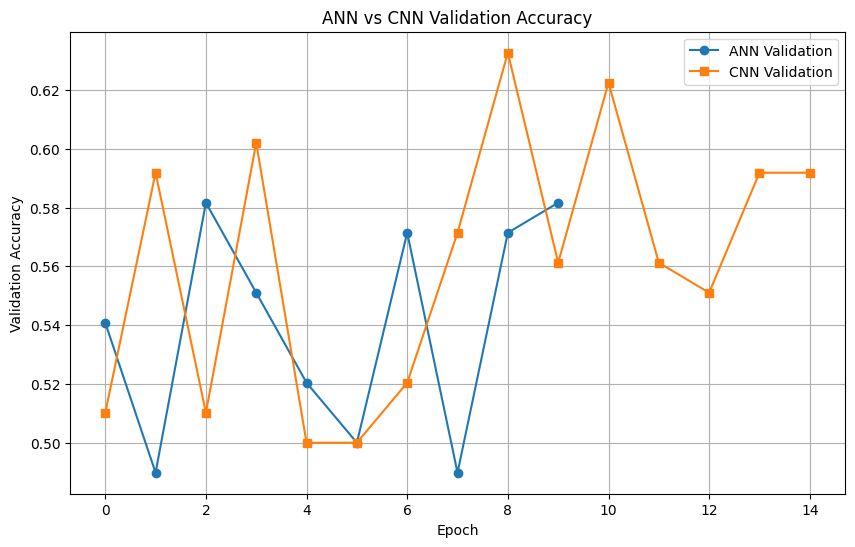

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the validation accuracy for both models
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# REDEFINE THESE HERE so the model knows the input size
IMG_HEIGHT = 128  # or 64, depending on what you chose earlier
IMG_WIDTH = 128
BATCH_SIZE = 32

# Build the CNN
cnn_model = keras.Sequential([
    # First Conv layer: 32 filters, 3x3 kernel
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv layer: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Conv layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the CNN
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 753ms/step - accuracy: 0.4800 - loss: 0.7337 - val_accuracy: 0.5102 - val_loss: 0.6928
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 673ms/step - accuracy: 0.5200 - loss: 0.6939 - val_accuracy: 0.5918 - val_loss: 0.6922
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 771ms/step - accuracy: 0.6225 - loss: 0.6873 - val_accuracy: 0.5102 - val_loss: 0.6954
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 771ms/step - accuracy: 0.5575 - loss: 0.6745 - val_accuracy: 0.6020 - val_loss: 0.6899
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 737ms/step - accuracy: 0.5725 - loss: 0.6717 - val_accuracy: 0.5000 - val_loss: 0.7037
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 674ms/step - accuracy: 0.5825 - loss: 0.6838 - val_accuracy: 0.5000 - val_loss: 0.7263
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 769ms/step - accuracy: 0.6575 - loss: 0.6442 - val_accuracy: 0.5204 - val_loss: 0.7734
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 793ms/step - accuracy: 0.6500 - loss: 0.6278 - val_accur

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 318ms/step - accuracy: 0.5000 - loss: 4.7380 - val_accuracy: 0.5408 - val_loss: 1.4886
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.5700 - loss: 1.1329 - val_accuracy: 0.4898 - val_loss: 2.3471
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.5950 - loss: 1.0015 - val_accuracy: 0.5816 - val_loss: 0.9007
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.6575 - loss: 0.8216 - val_accuracy: 0.5510 - val_loss: 1.1882
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.6900 - loss: 0.6241 - val_accuracy: 0.5204 - val_loss: 0.8794
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.6700 - loss: 0.6320 - val_accuracy: 0.5000 - val_loss: 0.9639
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.7575 - loss: 0.4549 - val_accuracy: 0.5714 - val_loss: 0.8835
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.6725 - loss: 0.6212 - val_accuracy: 0.

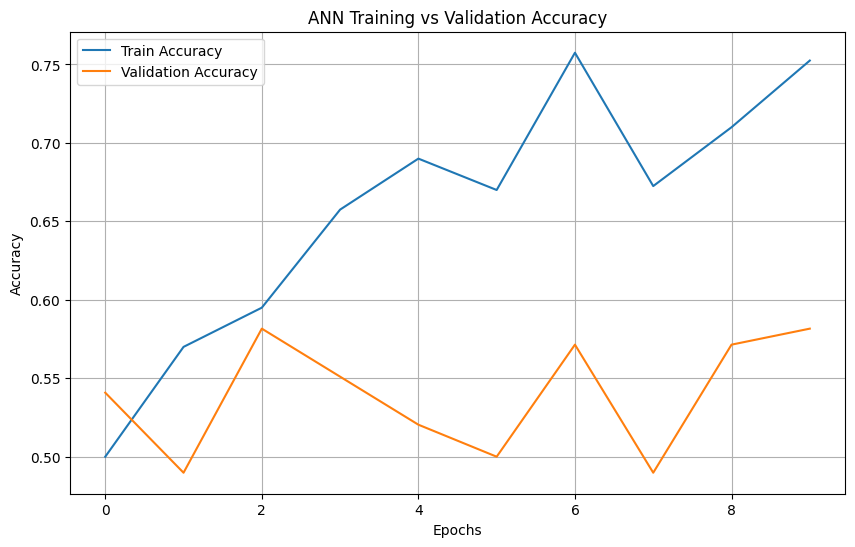

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Build a simple ANN
ann_model = keras.Sequential([
    # Flatten the 2D image (128x128x3) into a 1D vector
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output layer: sigmoid is used for binary (hot dog vs not)
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
ann_model.summary()

# Train for 10 epochs
history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Plot training vs validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Updated image size to 128x128
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Create generators with automatic labeling
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    validation_split=0.2     # Use 20% for validation
)

# Setup the training generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Setup the validation generator
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Print the class labels to verify
print(f"Class indices: {train_generator.class_indices}")

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class indices: {'hot_dog': 0, 'not_hot_dog': 1}


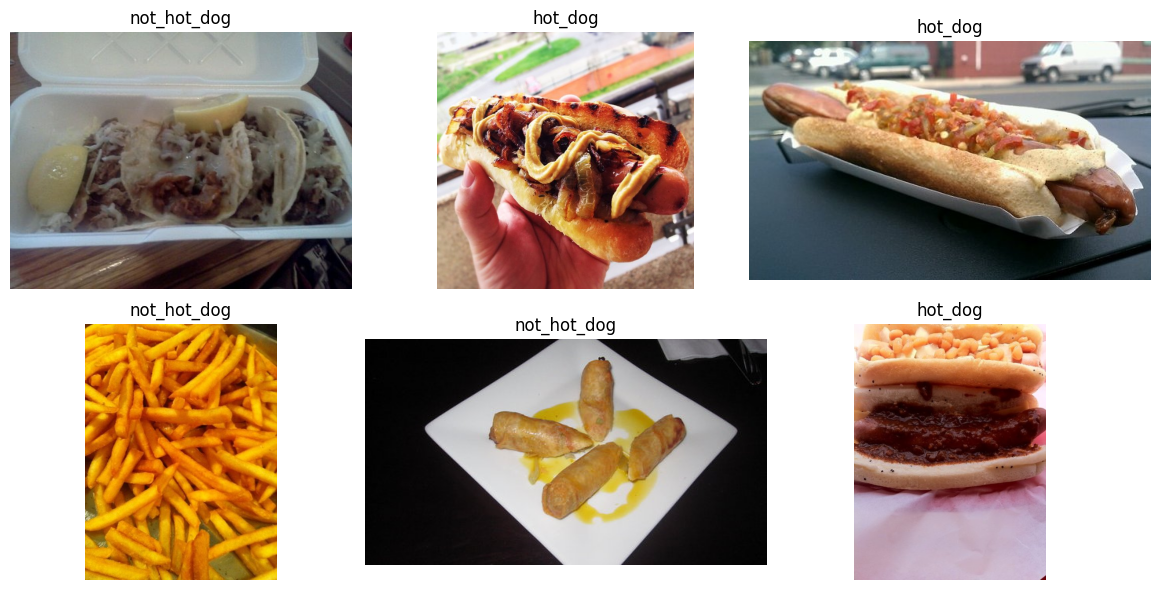

Image shape (height, width, channels): (512, 382, 3)


In [ ]:
import matplotlib.pyplot as plt
import random
import os

# Display 6 random images
plt.figure(figsize=(12, 6))
for i in range(6):
    # Pick random class - Fixed the spaces inside the strings
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# YOUR CODE HERE: Print the shape
print(f"Image shape (height, width, channels): {img.shape}")

In [ ]:
import os

# Updated paths based on your Kaggle folder structure
train_path = "/kaggle/input/hot-dog-not-hot-dog/train"
test_path = "/kaggle/input/hot-dog-not-hot-dog/test"

# Count training images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")

# YOUR CODE HERE: Count test images
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Test Hot dog images: {test_hot_dog_count}")
print(f"Test Not hot dog images: {test_not_hot_dog_count}")

Hot dog images: 249
Not hot dog images: 249
Test Hot dog images: 250
Test Not hot dog images: 250


In [ ]:
import numpy as np
import matplotlib . pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow . keras import layers
from tensorflow . keras . preprocessing . image import ImageDataGenerator
import os
import random
print ( " Libraries loaded successfully ! " )
print ( " TensorFlow version : " , tf . __version__ )

 Libraries loaded successfully ! 
 TensorFlow version :  2.20.0


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/hot-dog-not-hot-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hot-dog-not-hot-dog' dataset.
Path to dataset files: /kaggle/input/hot-dog-not-hot-dog
